# GeoTIFF Inference and Cluster Comparison

Run the trained SegFormer model directly on a raw NAIP GeoTIFF using a sliding window, then compare the predictions against a clustering mask exported from Google Earth Engine.

| File | Description |
|---|---|
| `naip_rgb.tif` | NAIP RGB at 0.6m — used for model inference |
| `naip_rgbn.tif` | NAIP with near-infrared at 0.6m — displayed for reference |
| `gee_embedding.tif` | Google Earth Engine feature embedding |
| `clustering_mask.tif` | 3-cluster result to compare against model output |

> **Resolution note:** The model was trained at 0.5m. NAIP is 0.6m (~18% scale difference). Predictions will run fine but spatial features will appear slightly smaller than at training scale. Set `RESAMPLE_TO_05M = True` in the config cell to resample first.

## 1. Setup

In [13]:
import sys
import math
import numpy as np
import torch
import rasterio
import rasterio.enums
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm import tqdm

In [14]:
# Update these paths to point to your GeoTIFF files.
DATA_DIR    = Path('data')
OUTPUT_DIR  = Path('data/predictions')
WEIGHTS_DIR = Path('../DroneClassification/bio_infra/weights')

NAIP_RGB_PATH  = DATA_DIR / '1_NAIP_06m_RGB.tif'
NAIP_RGBN_PATH = DATA_DIR / '2_NAIP_06m_Infrared.tif'
GEE_EMBED_PATH = DATA_DIR / '3_AlphaEarth_10m_Raw_64D.tif'
CLUSTER_PATH   = DATA_DIR / '4_AlphaEarth_10m_Cluster_Mask.tif'
PRED_PATH      = OUTPUT_DIR / 'prediction.tif'

MODEL_WEIGHTS     = WEIGHTS_DIR / 'mangrove_segformer.pth'
TILE_SIZE         = 512
NUM_CLASSES       = 1
RESAMPLE_TO_05M   = False

CLASS_NAMES  = ['not_mangrove', 'mangrove']
CLASS_COLORS = {
    0: [0.8, 0.8, 0.8],
    1: [0.0, 0.7, 0.0],
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device:    {device}')
print(f'Tile size: {TILE_SIZE}px')
print(f'Weights:   {MODEL_WEIGHTS}')

Device:    cuda
Tile size: 512px
Weights:   ..\DroneClassification\bio_infra\weights\mangrove_segformer.pth


## 2. Load Model

In [15]:
sys.path.insert(0, '../DroneClassification/')
from models import SegFormer

model = SegFormer(num_classes=NUM_CLASSES)
state_dict = torch.load(MODEL_WEIGHTS, map_location=device)
model.load_state_dict(state_dict)
model = model.to(device).eval()
print(f'Loaded weights from {MODEL_WEIGHTS}')

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerModel LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                                           | Status     |  | 
----------------------------------------------+------------+--+-
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | UNEXPECTED |  | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | UNEXPECTED |  | 
decode_head.batch_norm.running_var            | UNEXPECTED |  | 
decode_head.linear_fuse.weight                | UNEXPECTED |  | 
decode_head.classifier.bias                   | UNEXPECTED |  | 
decode_head.classifier.weight                 | UNEXPECTED |  | 
decode_head.batch_norm.bias                   | UNEXPECTED |  | 
decode_head.batch_norm.num_batches_tracked    | UNEXPECTED |  | 
decode_head.batch_norm.weight                 | UNEXPECTED |  | 
decode_head.batch_norm.running_mean           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded weights from ..\DroneClassification\bio_infra\weights\mangrove_segformer.pth


## 3. Inference Functions

`predict_tile` runs a single 512×512 tile through the model. `predict_geotiff` slides that window across the full image, pads any partial edge tiles, and stitches the results back into a full-resolution prediction. The output is saved as a GeoTIFF with the same CRS and spatial transform as the input so it stays geospatially aligned.

In [16]:
def predict_tile(model, tile, device):
    """
    Run inference on a single image tile.

    Args:
        tile: numpy array (H, W, 3), uint8 values 0-255.

    Returns:
        Class index map (H, W), uint8, values 0 to NUM_CLASSES-1.
    """
    image = tile.astype(np.float32) / 255.0
    mean  = np.array([0.485, 0.456, 0.406])
    std   = np.array([0.229, 0.224, 0.225])
    image = (image - mean) / std

    tensor = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).float().to(device)

    with torch.no_grad():
        output = model(tensor)
        pred = (torch.sigmoid(output) > 0.5).squeeze().cpu().numpy().astype(np.uint8)

    return pred.astype(np.uint8)

In [17]:
def predict_geotiff(model, src_path, out_path, tile_size, device):
    """
    Slide a window across a GeoTIFF and save the full prediction as a new GeoTIFF.

    Partial tiles at the right and bottom edges are zero-padded to the full tile
    size before inference, then cropped back to their original size when stitching.
    The output file inherits the CRS and spatial transform of the input.
    """
    with rasterio.open(src_path) as src:
        image = src.read()[:3].transpose(1, 2, 0)  # Take only RGB bands.
        h, w  = image.shape[:2]
        meta  = src.meta.copy()

    n_tiles = math.ceil(h / tile_size) * math.ceil(w / tile_size)
    print(f'Image: {w} x {h} pixels  |  {n_tiles} tiles at {tile_size}px')

    prediction = np.zeros((h, w), dtype=np.uint8)

    with tqdm(total=n_tiles, desc='Inference') as pbar:
        for y in range(0, h, tile_size):
            for x in range(0, w, tile_size):
                y2, x2 = min(y + tile_size, h), min(x + tile_size, w)
                tile   = image[y:y2, x:x2]

                if tile.shape[0] < tile_size or tile.shape[1] < tile_size:
                    pad = np.zeros((tile_size, tile_size, 3), dtype=tile.dtype)
                    pad[:tile.shape[0], :tile.shape[1]] = tile
                    tile = pad

                pred = predict_tile(model, tile, device)
                prediction[y:y2, x:x2] = pred[:y2 - y, :x2 - x]
                pbar.update(1)

    meta.update(dtype=rasterio.uint8, count=1, nodata=None)
    with rasterio.open(out_path, 'w', **meta) as dst:
        dst.write(prediction, 1)

    print(f'Saved to {out_path}')
    return prediction

## 4. Run Inference on NAIP RGB

In [18]:
prediction = predict_geotiff(model, NAIP_RGB_PATH, PRED_PATH, TILE_SIZE, device)

print()
print('Class distribution across the full image:')
for c, name in enumerate(CLASS_NAMES):
    pct = (prediction == c).sum() / prediction.size * 100
    print(f'  {name:<12} {pct:>5.1f}%')

Image: 14844 x 7423 pixels  |  435 tiles at 512px


Inference: 100%|██████████| 435/435 [00:40<00:00, 10.87it/s]


Saved to data\predictions\prediction.tif

Class distribution across the full image:
  not_mangrove  68.8%
  mangrove      31.2%


## 5. Load Reference Data

All four files are loaded here. A downsampled copy of each is kept for display so the visualization stays fast regardless of the original image size.

In [19]:
MAX_DISPLAY_PX = 1024

def load_tiff(path, max_px=MAX_DISPLAY_PX):
    """Return (full_array, display_array) for a GeoTIFF. Both are CHW numpy arrays."""
    with rasterio.open(path) as src:
        full    = src.read()
        h, w    = src.height, src.width
        scale   = min(max_px / h, max_px / w, 1.0)
        dh, dw  = int(h * scale), int(w * scale)
        display = src.read(
            out_shape=(src.count, dh, dw),
            resampling=rasterio.enums.Resampling.nearest
        )
    return full, display


print('Loading NAIP RGB...')
naip_rgb_full,  naip_rgb_disp  = load_tiff(NAIP_RGB_PATH)
print(f'  {naip_rgb_full.shape}  (C x H x W)')

print('Loading NAIP RGBN...')
naip_rgbn_full, naip_rgbn_disp = load_tiff(NAIP_RGBN_PATH)
print(f'  {naip_rgbn_full.shape}')

print('Loading GEE embedding...')
gee_full,       gee_disp       = load_tiff(GEE_EMBED_PATH)
print(f'  {gee_full.shape}')

print('Loading clustering mask...')
cluster_full,   cluster_disp   = load_tiff(CLUSTER_PATH)
print(f'  {cluster_full.shape}')
cluster_full  = cluster_full.squeeze()
cluster_disp  = cluster_disp.squeeze()

print('Loading prediction...')
pred_full,      pred_disp      = load_tiff(PRED_PATH)
pred_full = pred_full.squeeze()
pred_disp = pred_disp.squeeze()

cluster_values = np.unique(cluster_full)
print(f'\nDone. Cluster values found: {cluster_values.tolist()}')

Loading NAIP RGB...
  (3, 7423, 14844)  (C x H x W)
Loading NAIP RGBN...
  (3, 7423, 14844)
Loading GEE embedding...
  (64, 446, 892)
Loading clustering mask...
  (1, 446, 892)
Loading prediction...

Done. Cluster values found: [0, 1, 2]


## 6. Comparison Visualization

Four panels side by side: the raw RGB image, a NIR false-color composite (NIR-R-G, which highlights vegetation), the model prediction, and the clustering mask.

C:\Users\adytc\AppData\Local\Temp\ipykernel_73288\2147674488.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cluster_cmap   = plt.cm.get_cmap('Set2', len(cluster_values))


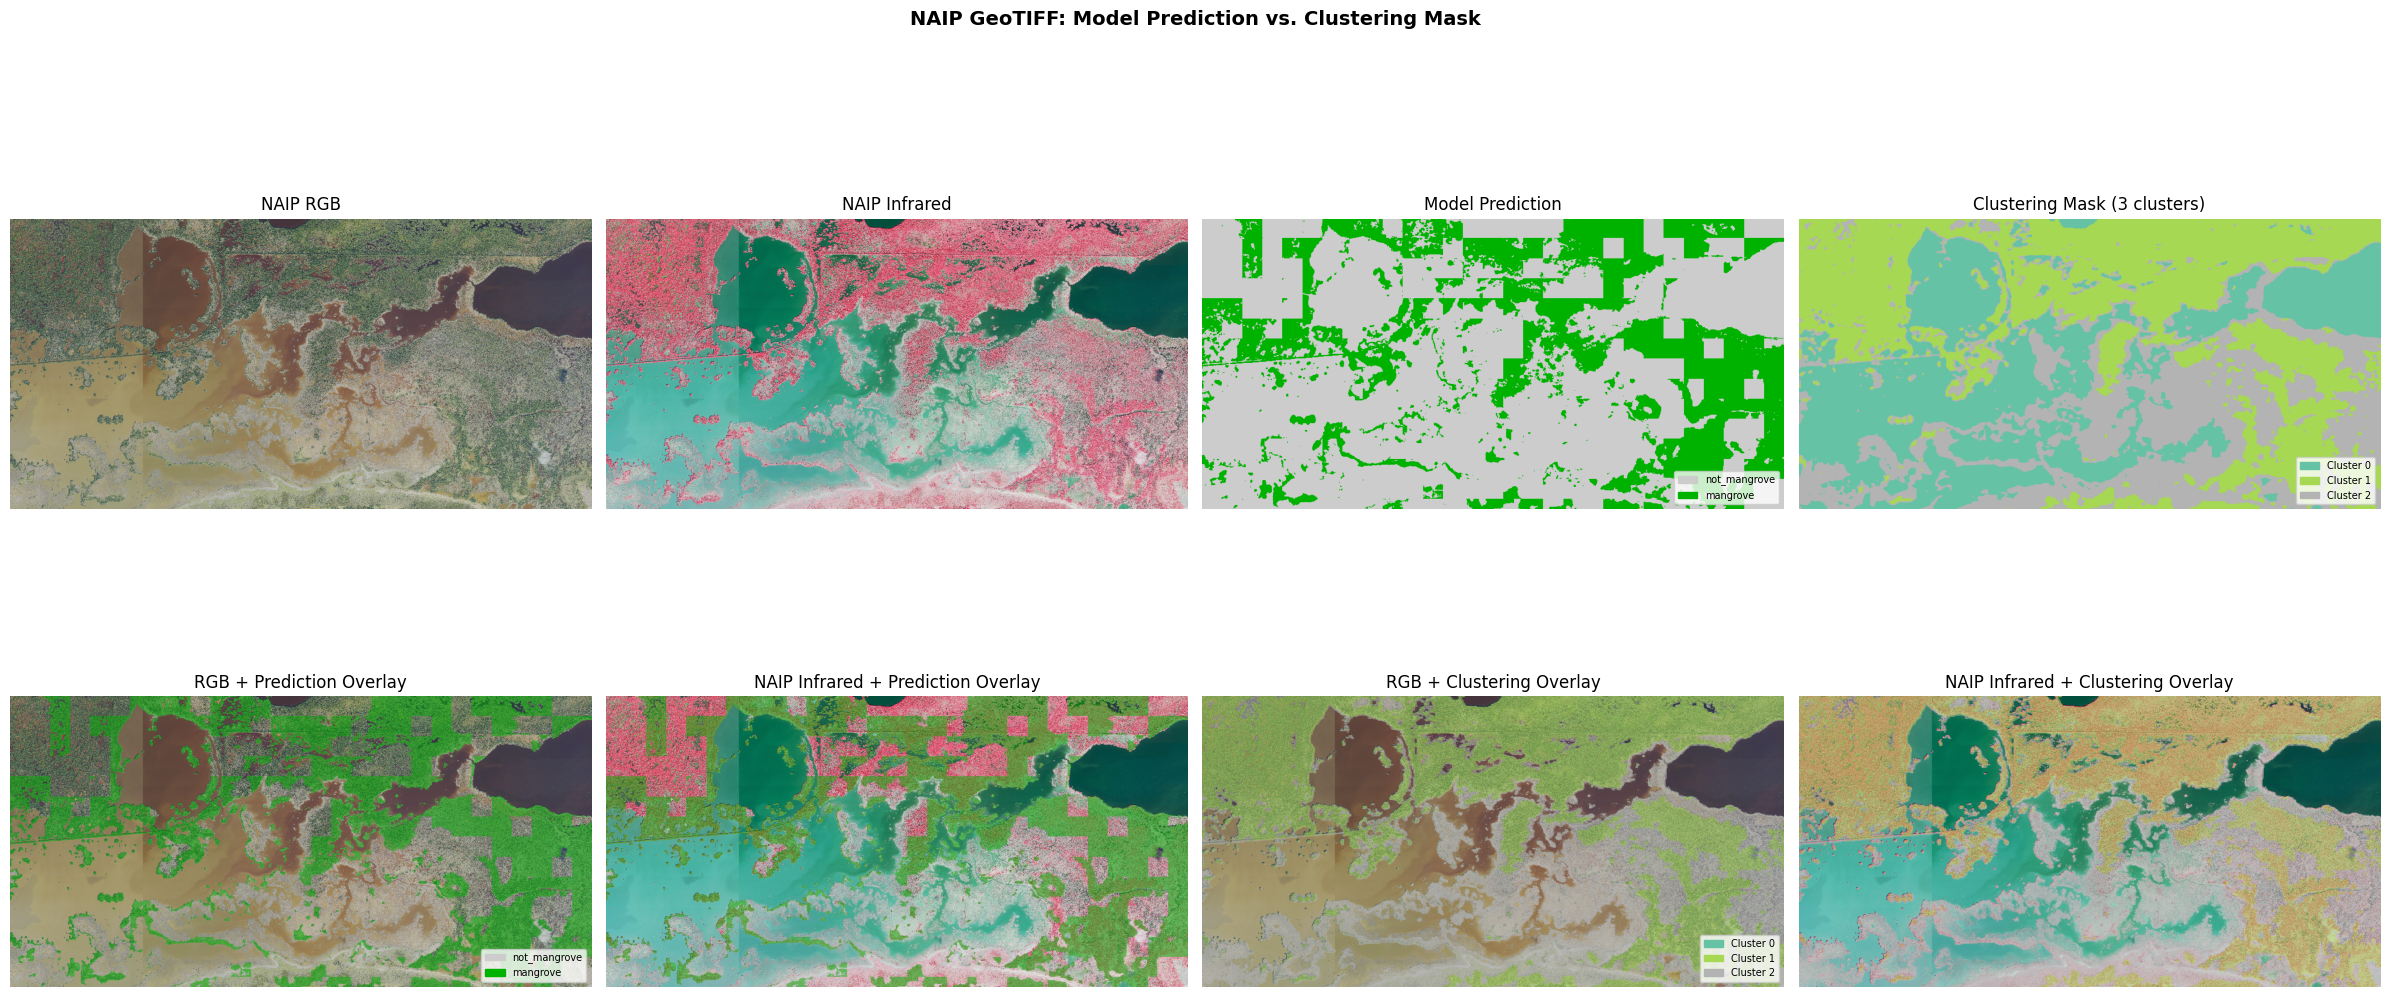

Saved to data\predictions\comparison.png


In [20]:
def mask_to_rgb(mask, color_map):
    """Convert an integer class mask to a float RGB image using the provided color map."""
    rgb = np.zeros((*mask.shape, 3), dtype=np.float32)
    for class_id, color in color_map.items():
        rgb[mask == class_id] = color
    return rgb


def to_uint8_hwc(arr):
    """Convert a CHW array with values 0-255 or 0-1 to a display-ready HWC uint8 array."""
    arr = arr.transpose(1, 2, 0).astype(np.float32)
    if arr.max() > 1.5:
        arr = arr / 255.0
    return np.clip(arr, 0, 1)


def make_nir_display(arr):
    """
    Build a displayable image from the infrared tiff.
    If it has 4 bands, compose a NIR-R-G false color (band indices 3, 0, 1).
    If it has 3 bands or fewer, just display it as-is.
    """
    if arr.shape[0] >= 4:
        img = to_uint8_hwc(arr[[3, 0, 1]])
    else:
        img = to_uint8_hwc(arr[:3])
    return img / img.max() if img.max() > 0 else img


def make_overlay(rgb, mask, color_map, alpha=0.5):
    """
    Blend a class mask over an RGB image at the given opacity.
    Class 0 (background) is left unchanged so only positive predictions are visible.
    """
    overlay = rgb.copy()
    for class_id, color in color_map.items():
        if class_id == 0:
            continue
        region = mask == class_id
        overlay[region] = (1 - alpha) * rgb[region] + alpha * np.array(color)
    return np.clip(overlay, 0, 1)


def resize_nearest(arr, new_h, new_w):
    """Resize a 2D integer array to (new_h, new_w) using nearest-neighbor interpolation."""
    old_h, old_w = arr.shape
    row_idx = (np.arange(new_h) * old_h / new_h).astype(int)
    col_idx = (np.arange(new_w) * old_w / new_w).astype(int)
    return arr[np.ix_(row_idx, col_idx)]


rgb_disp = to_uint8_hwc(naip_rgb_disp[:3])
nir_disp = make_nir_display(naip_rgbn_disp)

cluster_cmap   = plt.cm.get_cmap('Set2', len(cluster_values))
cluster_colors = {int(v): cluster_cmap(i)[:3] for i, v in enumerate(cluster_values)}

# The clustering mask is at a coarser resolution than NAIP, so resize it to
# match the RGB display dimensions before overlaying.
dh, dw = rgb_disp.shape[:2]
cluster_disp_resized = resize_nearest(cluster_disp, dh, dw)

pred_rgb  = mask_to_rgb(pred_disp,    CLASS_COLORS)
clust_rgb = mask_to_rgb(cluster_disp, cluster_colors)

pred_overlay_rgb  = make_overlay(rgb_disp, pred_disp,            CLASS_COLORS)
pred_overlay_nir  = make_overlay(nir_disp, pred_disp,            CLASS_COLORS)
clust_overlay_rgb = make_overlay(rgb_disp, cluster_disp_resized, cluster_colors)
clust_overlay_nir = make_overlay(nir_disp, cluster_disp_resized, cluster_colors)

nir_title = 'NAIP NIR-R-G (false color)' if naip_rgbn_disp.shape[0] >= 4 else 'NAIP Infrared'

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
fig.suptitle('NAIP GeoTIFF: Model Prediction vs. Clustering Mask', fontsize=14, fontweight='bold')

# Row 1: raw outputs.
axes[0, 0].imshow(rgb_disp);        axes[0, 0].set_title('NAIP RGB');             axes[0, 0].axis('off')
axes[0, 1].imshow(nir_disp);        axes[0, 1].set_title(nir_title);              axes[0, 1].axis('off')
axes[0, 2].imshow(pred_rgb);        axes[0, 2].set_title('Model Prediction');     axes[0, 2].axis('off')
axes[0, 3].imshow(clust_rgb);       axes[0, 3].set_title(f'Clustering Mask ({len(cluster_values)} clusters)'); axes[0, 3].axis('off')

model_legend   = [mpatches.Patch(color=CLASS_COLORS[c],    label=CLASS_NAMES[c])      for c in range(len(CLASS_NAMES))]
cluster_legend = [mpatches.Patch(color=cluster_cmap(i)[:3], label=f'Cluster {v}')    for i, v in enumerate(cluster_values)]
axes[0, 2].legend(handles=model_legend,   loc='lower right', fontsize=7, framealpha=0.8)
axes[0, 3].legend(handles=cluster_legend, loc='lower right', fontsize=7, framealpha=0.8)

# Row 2: overlays.
axes[1, 0].imshow(pred_overlay_rgb);  axes[1, 0].set_title('RGB + Prediction Overlay');          axes[1, 0].axis('off')
axes[1, 1].imshow(pred_overlay_nir);  axes[1, 1].set_title(f'{nir_title} + Prediction Overlay'); axes[1, 1].axis('off')
axes[1, 2].imshow(clust_overlay_rgb); axes[1, 2].set_title('RGB + Clustering Overlay');           axes[1, 2].axis('off')
axes[1, 3].imshow(clust_overlay_nir); axes[1, 3].set_title(f'{nir_title} + Clustering Overlay'); axes[1, 3].axis('off')

axes[1, 0].legend(handles=model_legend,   loc='lower right', fontsize=7, framealpha=0.8)
axes[1, 2].legend(handles=cluster_legend, loc='lower right', fontsize=7, framealpha=0.8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {OUTPUT_DIR / "comparison.png"}')

## 7. Cluster Agreement Analysis

Since the cluster labels and model class labels don't share a common meaning, the most useful comparison is to ask: for each cluster, how are pixels distributed across the five model classes? A cluster that maps strongly to one class gives you confidence in both the model and the clustering. A cluster split across multiple classes suggests the two methods disagree on that region.

In [22]:
# The prediction (0.6m) and clustering mask (10m) are at different resolutions.
# Downsample the prediction to the cluster's pixel grid before comparing.
cluster_h, cluster_w = cluster_full.shape
with rasterio.open(PRED_PATH) as src:
    pred_resampled = src.read(
        1,
        out_shape=(cluster_h, cluster_w),
        resampling=rasterio.enums.Resampling.nearest
    )

pred_flat    = pred_resampled.flatten().astype(int)
cluster_flat = cluster_full.flatten().astype(int)

rows = []
for v in cluster_values:
    mask  = cluster_flat == v
    total = mask.sum()
    row   = {'cluster': f'Cluster {v}', 'pixels': int(total)}
    for k, name in enumerate(CLASS_NAMES):
        row[name] = (pred_flat[mask] == k).sum() / total * 100
    rows.append(row)

df = pd.DataFrame(rows).set_index('cluster')

print('Model class distribution within each cluster (%):')
print()
print(df[CLASS_NAMES].round(1).to_string())

Model class distribution within each cluster (%):

           not_mangrove  mangrove
cluster                          
Cluster 0          98.6       1.4
Cluster 1          40.2      59.8
Cluster 2          71.4      28.6


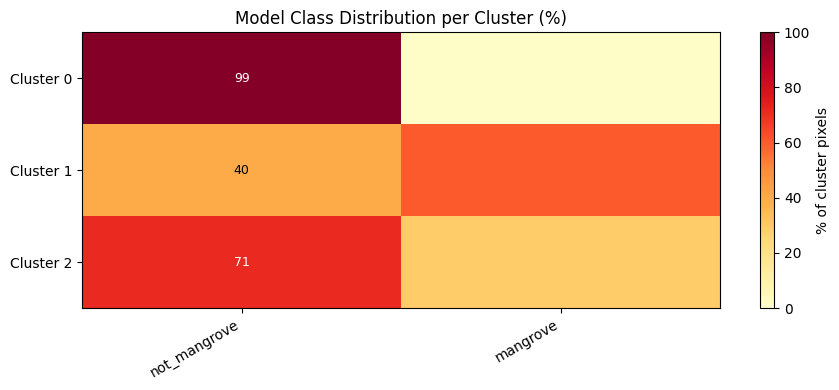

Saved to data\predictions\cluster_agreement.png


In [24]:
data = df[CLASS_NAMES].values

fig, ax = plt.subplots(figsize=(9, 1 + len(cluster_values)))
im = ax.imshow(data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(len(cluster_values)))
ax.set_yticklabels([f'Cluster {v}' for v in cluster_values], fontsize=10)
ax.set_title('Model Class Distribution per Cluster (%)', fontsize=12)

for i in range(len(cluster_values)):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f'{data[i, j]:.0f}', ha='center', va='center', fontsize=9,
                color='black' if data[i, j] < 70 else 'white')

plt.colorbar(im, ax=ax, label='% of cluster pixels')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cluster_agreement.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {OUTPUT_DIR / "cluster_agreement.png"}')